In [6]:
import yfinance as yf

ticker = "TITAN.NS"
stock = yf.Ticker(ticker)
fin = stock.financials

print(fin.loc[['Total Revenue', 'Gross Profit']])

                 2026-03-31    2025-03-31    2024-03-31    2023-03-31
Total Revenue  8.730500e+11  6.029800e+11  5.093600e+11  4.044700e+11
Gross Profit   1.694100e+11  1.278300e+11  1.144700e+11  1.003600e+11


In [7]:
import pandas as pd

data = fin.loc[['Total Revenue', 'Gross Profit']].T
data = data.sort_index()
data['Gross Margin'] = data['Gross Profit'] / data['Total Revenue']

print(data)

            Total Revenue  Gross Profit  Gross Margin
2023-03-31   4.044700e+11  1.003600e+11      0.248127
2024-03-31   5.093600e+11  1.144700e+11      0.224733
2025-03-31   6.029800e+11  1.278300e+11      0.211997
2026-03-31   8.730500e+11  1.694100e+11      0.194044


In [8]:
results = []
for i in range(1, len(data)):
    rev_prev = data['Total Revenue'].iloc[i-1]
    rev_curr = data['Total Revenue'].iloc[i]
    margin_prev = data['Gross Margin'].iloc[i-1]
    margin_curr = data['Gross Margin'].iloc[i]

    revenue_effect = (rev_curr - rev_prev) * margin_prev
    margin_effect = rev_curr * (margin_curr - margin_prev)

    results.append({
        'Year': data.index[i].year,
        'Revenue Effect': revenue_effect,
        'Margin Effect': margin_effect,
        'Total GP Change': revenue_effect + margin_effect
    })

decomp_df = pd.DataFrame(results).set_index('Year')
print(decomp_df)

      Revenue Effect  Margin Effect  Total GP Change
Year                                                
2024    2.602606e+10  -1.191606e+10     1.411000e+10
2025    2.103950e+10  -7.679503e+09     1.336000e+10
2026    5.725405e+10  -1.567405e+10     4.158000e+10


In [9]:
actual_change = data['Gross Profit'].diff().dropna()
print(actual_change)
print(decomp_df['Total GP Change'])
# these two should roughly match, year by year

2024-03-31    1.411000e+10
2025-03-31    1.336000e+10
2026-03-31    4.158000e+10
Name: Gross Profit, dtype: float64
Year
2024    1.411000e+10
2025    1.336000e+10
2026    4.158000e+10
Name: Total GP Change, dtype: float64


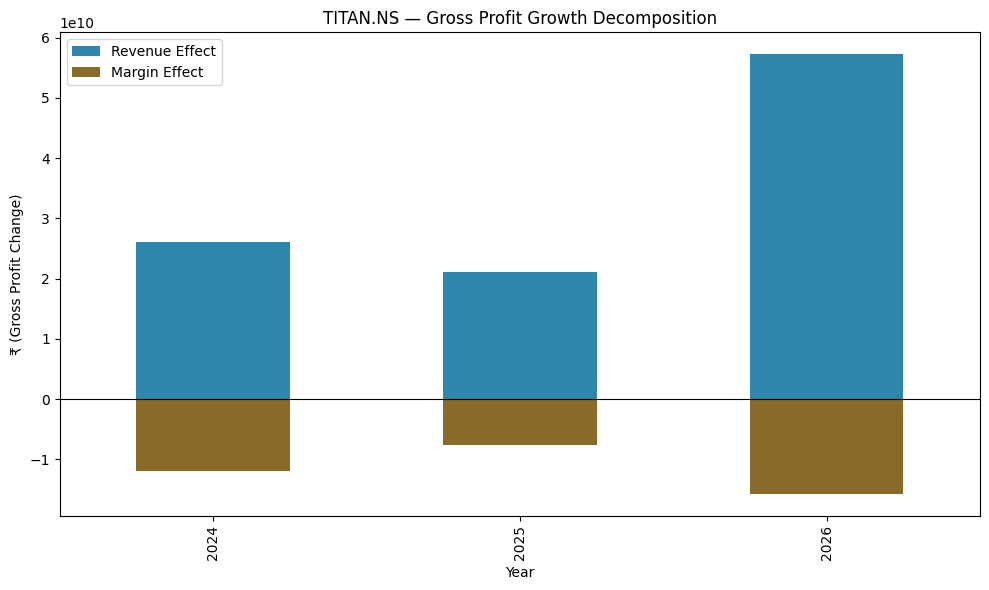

In [10]:
import matplotlib.pyplot as plt

decomp_df[['Revenue Effect','Margin Effect']].plot(
    kind='bar', stacked=True, figsize=(10,6), color=['#2E86AB','#8A6A28']
)
plt.axhline(0, color='black', linewidth=0.8)
plt.title(f'{ticker} — Gross Profit Growth Decomposition')
plt.ylabel('₹ (Gross Profit Change)')
plt.tight_layout()
plt.savefig('revenue_growth_decomposition.png')
plt.show()